# 6 · Classical-Network Effects on QKD

**The core QFabric contribution.** Pure quantum-network simulators assume an *ideal*
classical control channel. QFabric runs BB84's classical sifting over the real FABRIC
link, so we can measure how classical-network conditions affect QKD — something
SeQUeNCe/NetSquid cannot show.

Key point: because the classical channel is TCP (reliable), latency/jitter/loss do **not**
change QBER or bits-per-photon — they change **time-to-key** and effective **key bits/second**.
This notebook impairs *only* the classical channel (TCP:5100, leaving the photon data plane
untouched) across a set of conditions and plots the impact.

### At a glance
- **Purpose:** quantify how classical-channel latency/jitter/loss affect BB84 throughput.
- **Inputs:** `SLICE_NAME`, `SCENARIO`, and a list of network `conditions`.
- **Outputs:** `results/network_effects.json` + plots (bits/s, time-to-key, QBER per condition).
- **Runs on / runtime:** FABRIC JupyterHub; ~`len(conditions)` × a BB84 run (a few min each).
- **If something fails:** a severe condition may time out → that row is recorded as failed; netem is always cleared at the end (and on each iteration).

**Prerequisite:** `01_setup_slice` completed (switch running, data-plane IPs up).

## Configuration

In [1]:
SLICE_NAME = 'qfabric-bb84-2'
SCENARIO   = 'validation/scenarios/fabric_1km.yml'

In [2]:
import os, sys, json
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR)); sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
import deploy_fabric as df

fablib = df.get_fablib()
slice_obj = fablib.get_slice(name=SLICE_NAME)
slice_obj.show()

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
CEPH Manager,https://ceph-mgr.fabric-testbed.net
Token File,/home/fabric/work/fabric_config/id_token.json
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
Bastion Host,bastion.fabric-testbed.net
Bastion Username,audreyf_0000527467
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub


User: audreyf@illinois.edu bastion key is valid!
Configuration is valid


ID,d8ea8804-1e65-4186-a902-d6006de32667
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-07-28 21:27:56 +0000
Lease Start (UTC),2026-07-20 21:27:56 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


ID,d8ea8804-1e65-4186-a902-d6006de32667
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-07-28 21:27:56 +0000
Lease Start (UTC),2026-07-20 21:27:56 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


## Step 1 — Run BB84 under each classical-network condition
Each condition impairs only TCP:5100 (the sifting channel); photons are untouched. Edit
the list to taste — `delay_ms`, `jitter_ms`, `loss_pct`, or asymmetric `alice_delay_ms`/`bob_delay_ms`.

## Step 2 — Plots: throughput & time-to-key degrade, QBER stays flat
Loads `results/network_effects.json` (so this also re-plots a saved run). The story:
**bits/second and time-to-key respond to the classical channel; QBER does not** — the
effect ideal-channel simulators miss.

In [8]:
df_clean.to_csv('../results/joint_fault_atten_results.csv', index=False)

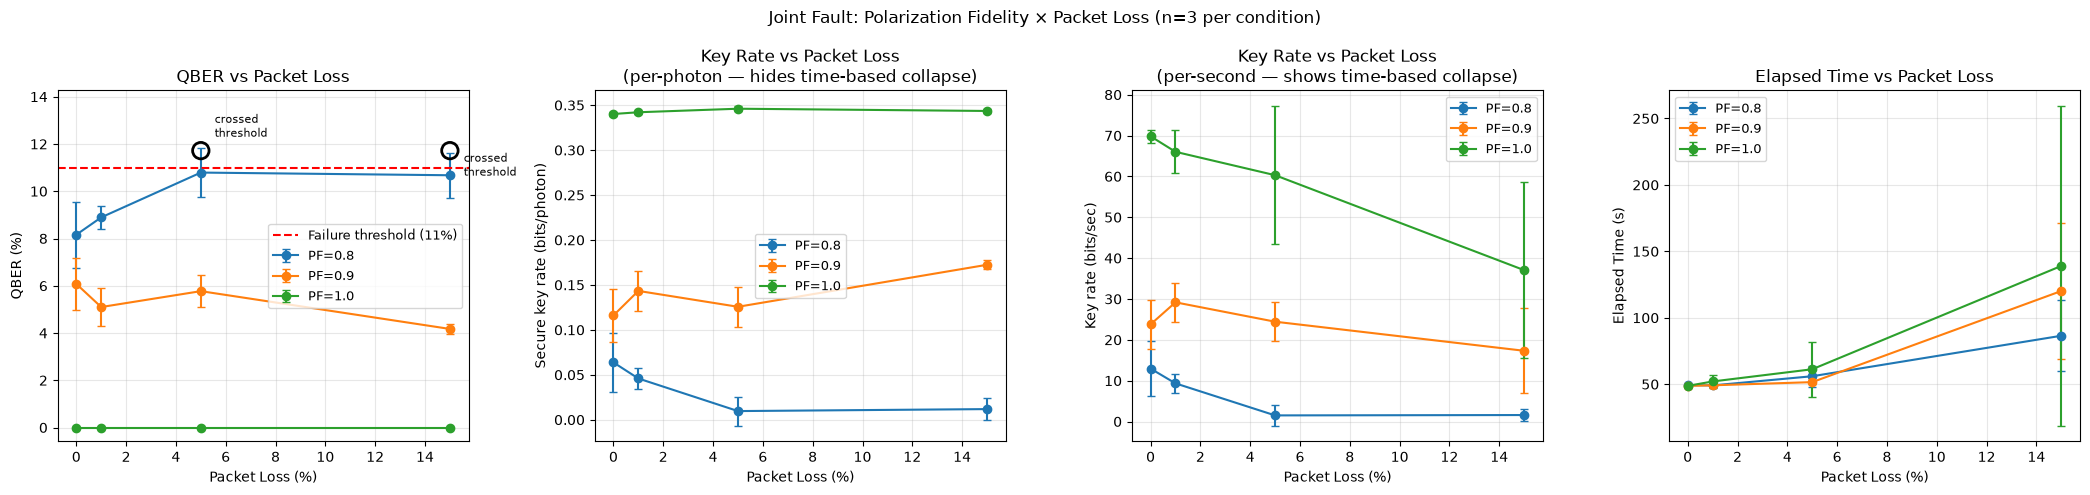

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_pf = pd.read_csv('../results/joint_fault_pf_results.csv')

df_pf['loss_pct'] = df_pf['loss_pct'].fillna(0)
for c in ['qber', 'sifted_bits', 'final_key_bits', 'secure_key_rate', 'elapsed_seconds', 'key_bits_per_sec']:
    df_pf[c] = pd.to_numeric(df_pf[c], errors='coerce')

pf_values = sorted(df_pf['polarization_fidelity'].unique())

agg = (
    df_pf.groupby(['polarization_fidelity', 'loss_pct'])
    .agg(
        qber_mean=('qber', 'mean'), qber_std=('qber', 'std'),
        keyrate_mean=('secure_key_rate', 'mean'), keyrate_std=('secure_key_rate', 'std'),
        bps_mean=('key_bits_per_sec', 'mean'), bps_std=('key_bits_per_sec', 'std'),
        elapsed_mean=('elapsed_seconds', 'mean'), elapsed_std=('elapsed_seconds', 'std'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(21, 5))
ax1, ax2, ax3, ax4 = axes

for pf in pf_values:
    subset = agg[agg['polarization_fidelity'] == pf].sort_values('loss_pct')
    label = f'PF={pf}'
    ax1.errorbar(subset['loss_pct'], subset['qber_mean'] * 100,
                 yerr=subset['qber_std'] * 100, marker='o', capsize=3, label=label)
    ax2.errorbar(subset['loss_pct'], subset['keyrate_mean'],
                 yerr=subset['keyrate_std'], marker='o', capsize=3, label=label)
    ax3.errorbar(subset['loss_pct'], subset['bps_mean'],
                 yerr=subset['bps_std'], marker='o', capsize=3, label=label)
    ax4.errorbar(subset['loss_pct'], subset['elapsed_mean'],
                 yerr=subset['elapsed_std'], marker='o', capsize=3, label=label)

ax1.axhline(y=11, color='red', linestyle='--', linewidth=1.5, label='Failure threshold (11%)')

# Mark individual runs that crossed threshold — annotate below/right of the line, out of the legend's way
crossing_rows = df_pf[(df_pf['qber'] * 100) >= 11]
for i, (_, row) in enumerate(crossing_rows.iterrows()):
    ax1.scatter(row['loss_pct'], row['qber'] * 100, s=140, facecolors='none',
                edgecolors='black', linewidths=2, zorder=5)
    # alternate annotation side so they don't overlap each other
    xytext = (10, -18) if i % 2 == 0 else (10, 10)
    ax1.annotate('crossed\nthreshold', (row['loss_pct'], row['qber'] * 100),
                 textcoords="offset points", xytext=xytext, fontsize=8,
                 ha='left')

ax1.set(xlabel='Packet Loss (%)', ylabel='QBER (%)', title='QBER vs Packet Loss')
ax1.legend(loc='center right', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_ylim(top=ax1.get_ylim()[1] * 1.15)  # headroom so annotations don't get clipped

ax2.set(xlabel='Packet Loss (%)', ylabel='Secure key rate (bits/photon)', title='Key Rate vs Packet Loss\n(per-photon — hides time-based collapse)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

ax3.set(xlabel='Packet Loss (%)', ylabel='Key rate (bits/sec)', title='Key Rate vs Packet Loss\n(per-second — shows time-based collapse)')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

ax4.set(xlabel='Packet Loss (%)', ylabel='Elapsed Time (s)', title='Elapsed Time vs Packet Loss')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.suptitle('Joint Fault: Polarization Fidelity × Packet Loss (n=3 per condition)')
plt.tight_layout()
plt.savefig('../results/joint_pf_loss_linegraph.png', dpi=150)
plt.show()

In [28]:
raw = df_plot[df_plot['attenuation'] == 0.1].sort_values(['loss_pct_plot', 'run'])
print(raw[['loss_pct_plot', 'run', 'qber', 'sifted_bits', 'final_key_bits',
           'elapsed_seconds', 'key_bits_per_sec']].to_string())

    loss_pct_plot  run      qber  sifted_bits  final_key_bits  elapsed_seconds  key_bits_per_sec
0             0.0    1  0.011688        38501           28289        91.064348        310.648468
4             0.0    2  0.010590        76493           57184       106.145286        538.733296
8             0.0    3  0.005195         7705            6284        49.250880        127.591628
1             1.0    1  0.010624         7532            5627        49.904509        112.755342
5             1.0    2  0.011378        76460           56455       153.851357        366.945089
9             1.0    3  0.011035        76129           56515       142.445860        396.747228
2             5.0    1  0.011373        76505           56494       235.443634        239.947027
6             5.0    2  0.012219        76936           56063       190.404912        294.440933
10            5.0    3  0.010344        76374           57317       209.751410        273.261572
3            15.0    1  0.0113

## Step 3 — Table

In [6]:
import pandas as pd
pd.DataFrame(rows)[['condition','qber','sifted_bits','final_key_bits','elapsed_seconds','key_bits_per_sec']]

,condition,qber,sifted_bits,final_key_bits,elapsed_seconds,key_bits_per_sec
0,baseline,0.007692,3906,3058,53.202664,57.478325
1,latency_10ms,0.015707,3826,2640,57.320260,46.057013
2,latency_25ms,0.013158,3802,2730,60.896272,44.830331
3,latency_50ms,0.010499,3819,2859,72.087245,39.660276
4,latency_75ms,0.005305,3774,3072,82.806415,37.098575
5,latency_100ms,0.018182,3850,2556,94.060594,27.173973
6,latency_150ms,0.021164,3787,2400,108.215190,22.178032
7,latency_200ms,0.000000,3785,3407,128.636914,26.485399
8,jitter_50pm5ms,0.012690,3949,2857,55.249436,51.710935
9,jitter_50pm10ms,0.005195,3851,3140,57.224360,54.871736


In [1]:
# import pandas as pd
# import json

# with open('../results/joint_network_effects.json') as f:
#     data = json.load(f)

# df = pd.DataFrame(data)
# df.to_csv('../results/joint_network_effects.csv', index=False)

---
This is the headline result: QFabric measures classical-network impact on QKD throughput.
Extend `conditions` (or add competing traffic) to map the operating envelope.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('../results/joint_fault_atten_results.json') as f:
    data = json.load(f)
df_joint = pd.DataFrame(data)

def plot_joint_heatmap(df, quantum_col, quantum_label, fault_conditions, fault_labels, metric, metric_label, title, filename):
    quantum_vals = sorted(df[quantum_col].unique())
    
    grid = np.zeros((len(quantum_vals), len(fault_conditions)))
    
    for i, qval in enumerate(quantum_vals):
        for j, cond in enumerate(fault_conditions):
            row = df[(df[quantum_col] == qval) & (df['condition'] == cond)]
            if len(row) > 0:
                grid[i, j] = row[metric].values[0]
            else:
                grid[i, j] = np.nan
    
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(grid, cmap='Reds' if metric == 'qber' else 'Blues_r', aspect='auto')
    ax.set_xticks(range(len(fault_conditions)))
    ax.set_xticklabels(fault_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(quantum_vals)))
    ax.set_yticklabels([f"{v}" for v in quantum_vals])
    ax.set_xlabel("Classical Fault Condition")
    ax.set_ylabel(quantum_label)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=metric_label)
    plt.tight_layout()
    plt.savefig(f'../results/{filename}', dpi=150)
    plt.show()

fault_conditions = ['baseline', 'latency_25ms', 'latency_100ms', 'latency_200ms',
                    'jitter_50pm10ms', 'loss_1pct', 'loss_5pct', 'loss_15pct', 'asymmetric_100_10']
fault_labels = ['baseline', 'lat 25ms', 'lat 100ms', 'lat 200ms',
                'jit ±10ms', 'loss 1%', 'loss 5%', 'loss 15%', 'asym 100/10']

# attenuation x classical - QBER
plot_joint_heatmap(df_joint, 'attenuation', 'Attenuation (dB/km)',
                   fault_conditions, fault_labels,
                   'qber', 'QBER',
                   'Mean QBER: Attenuation × Classical Fault',
                   'joint_atten_qber.png')

# attenuation x classical - key rate
plot_joint_heatmap(df_joint, 'attenuation', 'Attenuation (dB/km)',
                   fault_conditions, fault_labels,
                   'key_bits_per_sec', 'Key bits/sec',
                   'Key Rate: Attenuation × Classical Fault',
                   'joint_atten_keyrate.png')

In [ ]:
latency_conditions = ['baseline', 'latency_25ms', 'latency_100ms', 'latency_200ms']
latency_labels = ['baseline', '25ms', '100ms', '200ms']

jitter_conditions = ['baseline', 'jitter_50pm10ms', 'jitter_50pm30ms', 'jitter_50pm50ms']
jitter_labels = ['baseline', '±10ms', '±30ms', '±50ms']

loss_conditions = ['baseline', 'loss_1pct', 'loss_5pct', 'loss_15pct']
loss_labels = ['baseline', '1%', '5%', '15%']

for conditions, labels, fault_name in [
    (latency_conditions, latency_labels, 'latency'),
    (jitter_conditions, jitter_labels, 'jitter'),
    (loss_conditions, loss_labels, 'loss')
]:
    plot_joint_heatmap(df_joint, 'attenuation', 'Attenuation (dB/km)',
                       conditions, labels,
                       'qber', 'QBER',
                       f'Mean QBER: Attenuation × {fault_name.capitalize()}',
                       f'joint_atten_{fault_name}_qber.png')
    
    plot_joint_heatmap(df_joint, 'attenuation', 'Attenuation (dB/km)',
                       conditions, labels,
                       'key_bits_per_sec', 'Key bits/sec',
                       f'Key Rate: Attenuation × {fault_name.capitalize()}',
                       f'joint_atten_{fault_name}_keyrate.png')

# load distance results
with open('../results/joint_fault_dist_results.json') as f:
    data_dist = json.load(f)
df_dist = pd.DataFrame(data_dist)

# load polarization fidelity results
with open('../results/joint_fault_pf_results.json') as f:
    data_pf = json.load(f)
df_pf = pd.DataFrame(data_pf)

# distance heatmaps
for conditions, labels, fault_name in [
    (latency_conditions, latency_labels, 'latency'),
    (jitter_conditions, jitter_labels, 'jitter'),
    (loss_conditions, loss_labels, 'loss')
]:
    plot_joint_heatmap(df_dist, 'distance', 'Distance (km)',
                       conditions, labels,
                       'qber', 'QBER',
                       f'Mean QBER: Distance × {fault_name.capitalize()}',
                       f'joint_dist_{fault_name}_qber.png')
    
    plot_joint_heatmap(df_dist, 'distance', 'Distance (km)',
                       conditions, labels,
                       'key_bits_per_sec', 'Key bits/sec',
                       f'Key Rate: Distance × {fault_name.capitalize()}',
                       f'joint_dist_{fault_name}_keyrate.png')

# polarization fidelity heatmaps
for conditions, labels, fault_name in [
    (latency_conditions, latency_labels, 'latency'),
    (jitter_conditions, jitter_labels, 'jitter'),
    (loss_conditions, loss_labels, 'loss')
]:
    plot_joint_heatmap(df_pf, 'polarization_fidelity', 'Polarization Fidelity',
                       conditions, labels,
                       'qber', 'QBER',
                       f'Mean QBER: Polarization Fidelity × {fault_name.capitalize()}',
                       f'joint_pf_{fault_name}_qber.png')
    
    plot_joint_heatmap(df_pf, 'polarization_fidelity', 'Polarization Fidelity',
                       conditions, labels,
                       'key_bits_per_sec', 'Key bits/sec',
                       f'Key Rate: Polarization Fidelity × {fault_name.capitalize()}',
                       f'joint_pf_{fault_name}_keyrate.png')

In [27]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_pf = pd.read_csv('../results/joint_fault_pf_results.csv')
df_pf['loss_pct'] = df_pf['loss_pct'].fillna(0)
for c in ['qber', 'elapsed_seconds']:
    df_pf[c] = pd.to_numeric(df_pf[c], errors='coerce')

# Treat loss_pct and polarization_fidelity as categorical factors for a clean ANOVA
df_pf['loss_cat'] = df_pf['loss_pct'].astype(str)
df_pf['pf_cat'] = df_pf['polarization_fidelity'].astype(str)

# Test 1: does packet loss's effect on QBER depend on PF? (expect: no)
model_qber = ols('qber ~ C(pf_cat) + C(loss_cat) + C(pf_cat):C(loss_cat)', data=df_pf).fit()
anova_qber = sm.stats.anova_lm(model_qber, typ=2)
print("=== QBER ANOVA ===")
print(anova_qber)

# Test 2: does PF's effect on elapsed_seconds depend on loss? (expect: no, or check)
model_time = ols('elapsed_seconds ~ C(pf_cat) + C(loss_cat) + C(pf_cat):C(loss_cat)', data=df_pf).fit()
anova_time = sm.stats.anova_lm(model_time, typ=2)
print("\n=== Elapsed Time ANOVA ===")
print(anova_time)

=== QBER ANOVA ===
                         sum_sq    df           F        PR(>F)
C(pf_cat)              0.055817   2.0  513.510151  2.010026e-20
C(loss_cat)            0.000402   3.0    2.468278  8.644784e-02
C(pf_cat):C(loss_cat)  0.001783   6.0    5.469225  1.095989e-03
Residual               0.001304  24.0         NaN           NaN

=== Elapsed Time ANOVA ===
                             sum_sq    df         F    PR(>F)
C(pf_cat)               1362.931867   2.0  0.446752  0.644915
C(loss_cat)            27453.834938   3.0  5.999355  0.003356
C(pf_cat):C(loss_cat)   3049.896919   6.0  0.333240  0.912638
Residual               36609.051462  24.0       NaN       NaN


In [28]:
print(df_pf.groupby(['polarization_fidelity', 'loss_pct'])['qber'].mean().unstack())

loss_pct                   0.0       1.0       5.0       15.0
polarization_fidelity                                        
0.8                    0.081593  0.088941  0.107902  0.106768
0.9                    0.060791  0.050994  0.057720  0.041724
1.0                    0.000000  0.000000  0.000000  0.000000


In [29]:
import os, csv, json

FIELDNAMES_PF = ['condition', 'loss_pct', 'qber', 'sifted_bits', 'final_key_bits',
                  'secure_key_rate', 'elapsed_seconds', 'key_bits_per_sec',
                  'polarization_fidelity', 'run', 'note']

def run_pf08_topup(slice_obj, conditions, n_runs=4, start_run=4,
                     out_csv='../results/joint_fault_pf_results.csv'):
    """Add more replicates at PF=0.8 only, continuing run numbering from start_run."""
    pf = 0.8
    scenario_content = f"""name: pf_{pf}
channel:
  distance_km: 10.0
  attenuation_db_per_km: 0.2
  polarization_fidelity: {pf}
detector:
  efficiency: 0.8
  dark_count_rate: 10.0
  dead_time: 0.0
  timing_jitter: 0.0
protocol:
  num_photons: 10000
  send_rate_hz: 10000.0
  sample_fraction: 0.1
  wavelength: 0
seed: 42
"""
    scenario_path = f'../validation/scenarios/temp_pf_{pf}.yml'
    with open(scenario_path, 'w') as f:
        f.write(scenario_content)

    all_rows = []
    write_header = not os.path.exists(out_csv)
    total = len(conditions) * n_runs

    for run in range(n_runs):
        rows = deploy.run_network_conditions_experiment(slice_obj, scenario_path, conditions=conditions)
        for row in rows:
            row['polarization_fidelity'] = pf
            row['run'] = start_run + run  # continue numbering past your existing 1-3
            all_rows.append(row)
            with open(out_csv, 'a', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=FIELDNAMES_PF, extrasaction='ignore')
                if write_header:
                    writer.writeheader()
                    write_header = False
                writer.writerow(row)
        print(f"Progress: {(run+1)*len(conditions)}/{total} runs complete")

    return all_rows

conditions = (
    [{'name': 'baseline'}] +
    [{'name': f'loss_{l}pct', 'loss_pct': l} for l in [1, 5, 15]]
)

rows_topup = run_pf08_topup(slice_obj, conditions, n_runs=4, start_run=4)


##### [1/4] classical condition: baseline #####
  cleared classical netem on Alice and Bob

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 10000 photons on enp7s0
Alice: Finished sending 10000 photons
Alice: Connecting to Bob at 10.10.1.2:5100
  Retrying connection to 10.10.1.2:5100 (attempt 2/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 3/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 4/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 5/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 6/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 7/60)...
  Retrying connection to 10.1